#### Exploratory Data Analysis

In [ ]:
# Load the Dataset & Data Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("wine.csv")

# Basic exploration
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())


   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  
(178, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column   

In [ ]:
# Checking Missing Values
print(df.isnull().sum())


Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64


#### Distribution of Features

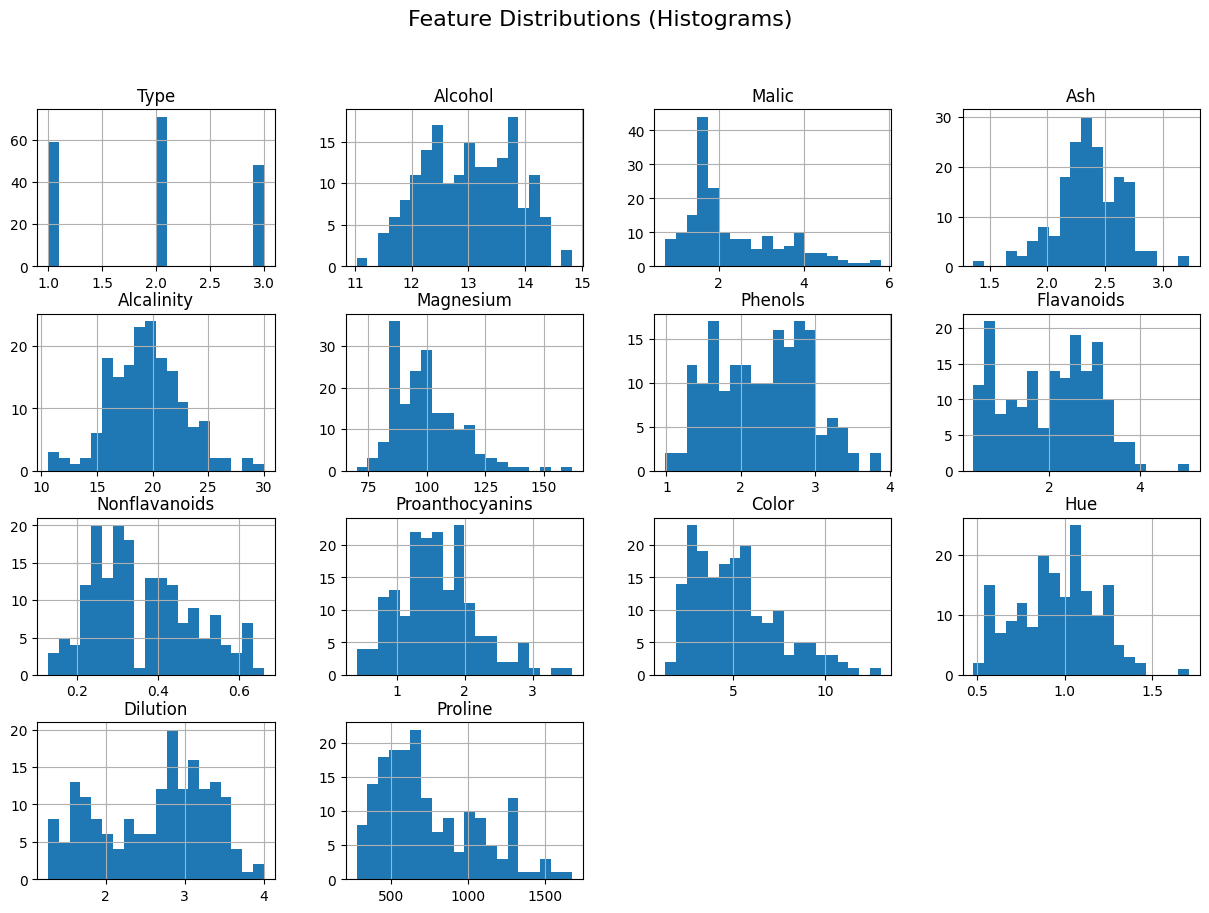

In [ ]:
# Histograms
df.hist(figsize=(15, 10), bins=20)
plt.suptitle("Feature Distributions (Histograms)", fontsize=16)
plt.show()


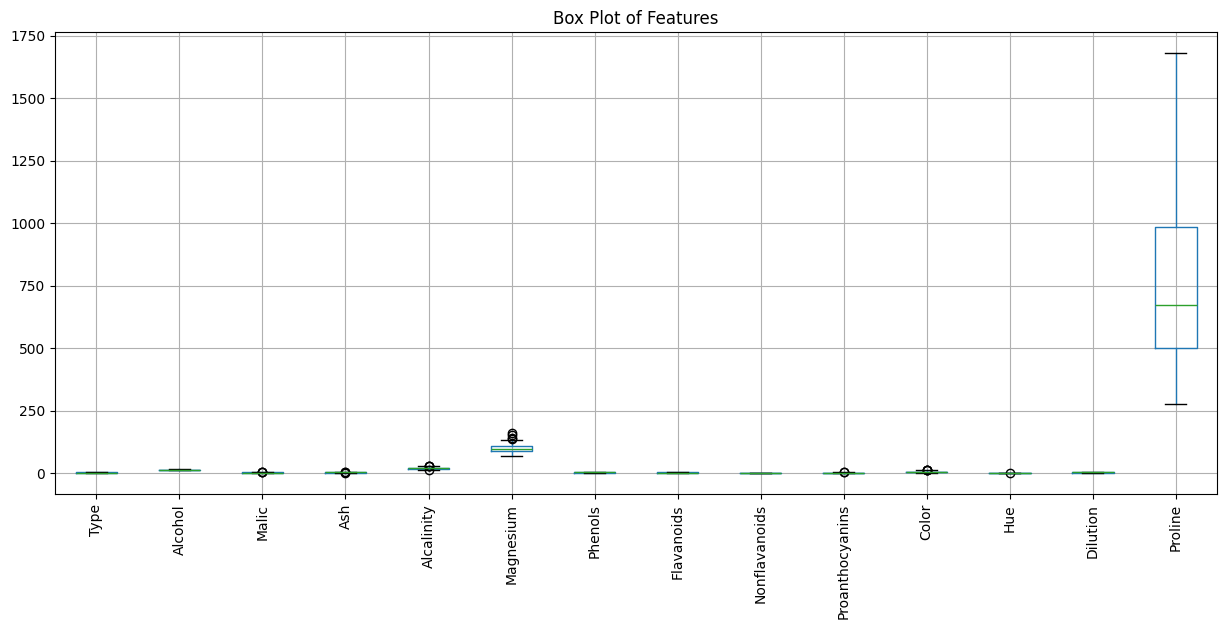

In [ ]:
# Box Plots
plt.figure(figsize=(15, 6))
df.boxplot()
plt.xticks(rotation=90)
plt.title("Box Plot of Features")
plt.show()


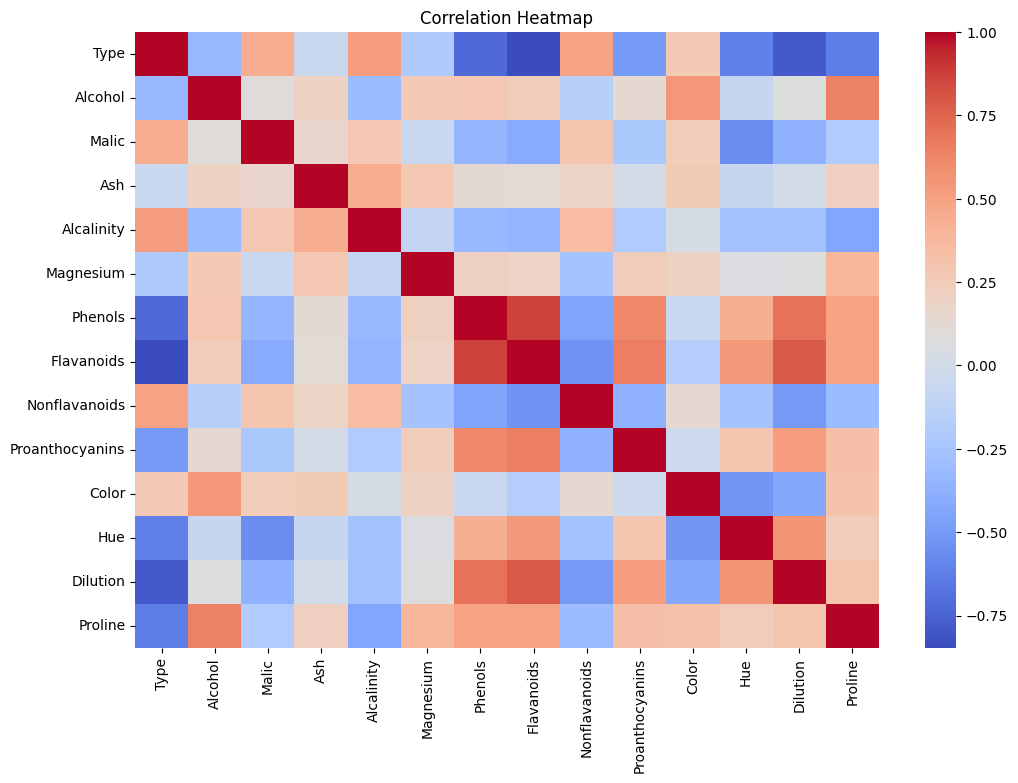

In [6]:
# Correlation Analysis
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


#### Dimensionality Reduction With PCA

In [8]:
# Standardise the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

print("Scaled data (first 5 rows):")
print(scaled_data[:5])


Scaled data (first 5 rows):
[[-1.21394365  1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522
   0.80899739  1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728
   1.84791957  1.01300893]
 [-1.21394365  0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502
   0.56864766  0.73362894 -0.82071924 -0.54472099 -0.29332133  0.40605066
   1.1134493   0.96524152]
 [-1.21394365  0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836
   0.80899739  1.21553297 -0.49840699  2.13596773  0.26901965  0.31830389
   0.78858745  1.39514818]
 [-1.21394365  1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845
   2.49144552  1.46652465 -0.98187536  1.03215473  1.18606801 -0.42754369
   1.18407144  2.33457383]
 [-1.21394365  0.29570023  0.22769377  1.84040254  0.45194578  1.28198515
   0.80899739  0.66335127  0.22679555  0.40140444 -0.31927553  0.36217728
   0.44960118 -0.03787401]]


In [10]:
# Apply PCA
from sklearn.decomposition import PCA

pca = PCA()
pca_data = pca.fit_transform(scaled_data)

print("PCA transformed data ( rows):")
print(pca_data[::-1])


PCA transformed data ( rows):
[[ 3.49633565e+00  2.76060799e+00  1.01315115e+00 ... -1.89866131e-01
  -1.64090011e-01 -2.64916504e-01]
 [ 2.75522166e+00  2.29378408e+00 -5.50473677e-01 ...  3.44119826e-01
  -1.09514873e-01  1.02823104e-01]
 [ 3.02727243e+00  2.75604024e+00 -9.40803036e-01 ...  6.93336340e-01
   1.67035660e-01 -3.16957430e-02]
 ...
 [-2.78502898e+00  1.03693595e+00  9.83237703e-01 ...  1.89799314e-03
   2.12780166e-02 -5.57515155e-02]
 [-2.52885806e+00 -3.30019252e-01 -2.02670665e+00 ...  3.94971160e-01
  -1.46645308e-01  1.26402355e-01]
 [-3.52293390e+00  1.45309844e+00 -1.64795488e-01 ...  5.52927766e-01
  -3.02978176e-01  2.00857450e-01]]


#### Determine Optimal NUmber Of Components

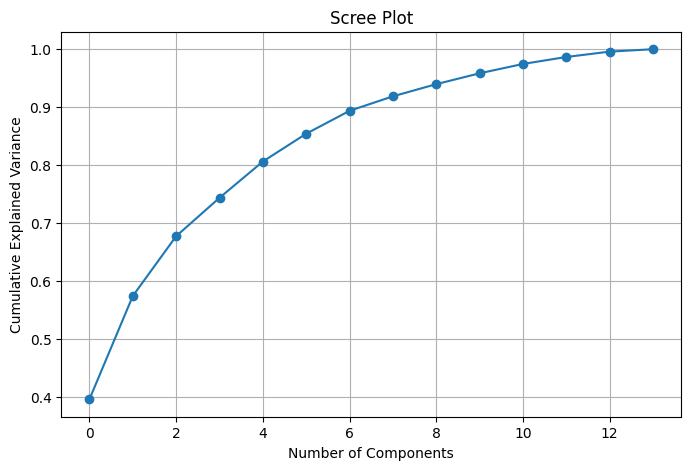

In [11]:
# Scree PLot
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.grid()
plt.show()


In [12]:
pca = PCA(n_components=0.95)
pca_data = pca.fit_transform(scaled_data)

print("Number of components selected:", pca.n_components_)


Number of components selected: 10


In [13]:
# Transformed Data
pca_df = pd.DataFrame(pca_data)
print(pca_df.head())


          0         1         2         3         4         5         6  \
0 -3.522934  1.453098 -0.164795 -0.013273  0.737345  0.300716  0.573876   
1 -2.528858 -0.330019 -2.026707 -0.417144 -0.283214  0.884309 -0.029716   
2 -2.785029  1.036936  0.983238  0.664232 -0.387565 -0.468842  0.488305   
3 -3.922588  2.768210 -0.174968  0.565088 -0.324360 -0.262616 -0.398364   
4 -1.407511  0.867773  2.025829 -0.440906  0.227949  0.593762  0.447876   

          7         8         9  
0 -0.055637 -0.458765 -1.065570  
1 -1.010372  0.218806  0.020182  
2  0.268957  1.222769  0.106249  
3 -0.618844 -0.114658 -0.107671  
4 -0.434937 -0.261548 -0.112434  


#### Clusterig With Original data

In [17]:
# Apply K-means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters_original = kmeans.fit_predict(scaled_data)

print("Cluster labels for original data (samples):")
print(clusters_original[::-1])


Cluster labels for original data (samples):
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


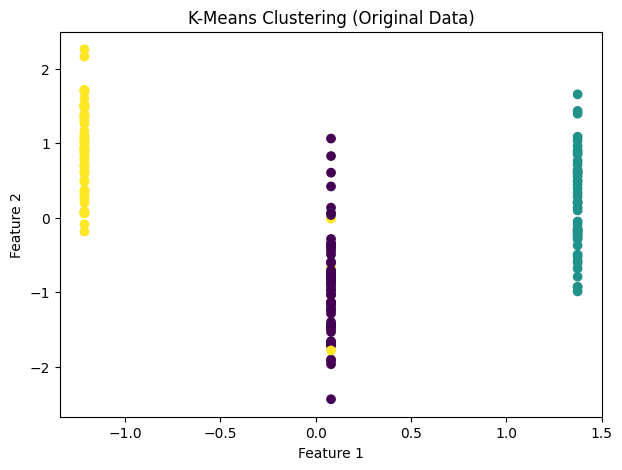

In [18]:
# Visualization
plt.figure(figsize=(7, 5))
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=clusters_original)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering (Original Data)")
plt.show()


In [19]:
# Clustering Evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_original = silhouette_score(scaled_data, clusters_original)
db_original = davies_bouldin_score(scaled_data, clusters_original)

print("Silhouette Score (Original):", silhouette_original)
print("Davies-Bouldin Index (Original):", db_original)


Silhouette Score (Original): 0.30648398324833453
Davies-Bouldin Index (Original): 1.315707552261773


#### Clustering With PCA Data

In [24]:
# Clustering Using PCA data
from sklearn.cluster import KMeans

kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(pca_data)

print("Clusters assigned using PCA data ( values):")
print(clusters_pca[::-1])


Clusters assigned using PCA data ( values):
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


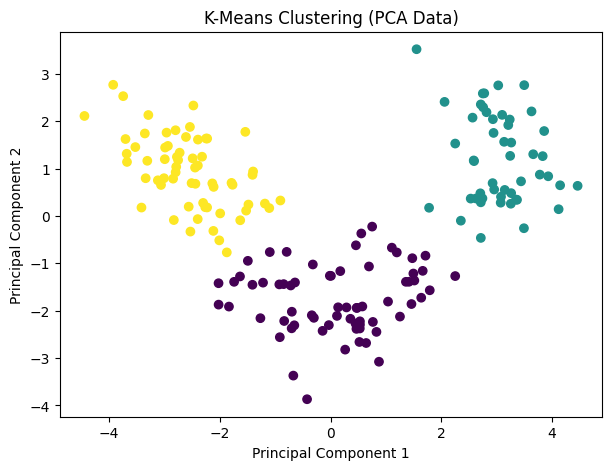

In [25]:
# Visualization
plt.figure(figsize=(7, 5))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters_pca)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering (PCA Data)")
plt.show()


In [26]:
# Evaluation
silhouette_pca = silhouette_score(pca_data, clusters_pca)
db_pca = davies_bouldin_score(pca_data, clusters_pca)

print("Silhouette Score (PCA):", silhouette_pca)
print("Davies-Bouldin Index (PCA):", db_pca)


Silhouette Score (PCA): 0.32292055407233017
Davies-Bouldin Index (PCA): 1.2578453408449173


#### Comparison and Analysis

In [27]:
comparison = pd.DataFrame({
    "Method": ["Original Data", "PCA Data"],
    "Silhouette Score": [silhouette_original, silhouette_pca],
    "Davies-Bouldin Index": [db_original, db_pca]
})

print(comparison)


          Method  Silhouette Score  Davies-Bouldin Index
0  Original Data          0.306484              1.315708
1       PCA Data          0.322921              1.257845


In [ ]:
# Clustering Results:

# PCA-based clustering often shows:

#Higher silhouette score

#Lower Davies–Bouldin index

# PCA removes noise and correlated features.

# Visualization is clearer in reduced dimensions.

In [ ]:
# Impact of PCA On Clustering:

#PCA improves cluster separation

#Reduces computational complexity

#Helps visualize high-dimensional data

In [ ]:
#| Aspect           | Original Data | PCA Data |
#| ---------------- | ------------- | -------- |
#| Interpretability | High          | Lower    |
#| Noise            | High          | Reduced  |
#| Visualization    | Difficult     | Easy     |
#| Speed            | Slower        | Faster   |


#### Conclusion and insights

In [ ]:
#Key Findings:

# PCA significantly reduces dimensionality while retaining most information.

# Clustering on PCA-transformed data often performs better.

# Correlated features negatively impact clustering quality.

In [ ]:
#Practical Implications:

# PCA + clustering is useful for:

# Customer segmentation

# Pattern recognition

# Data compression

In [ ]:
#Recommendations:

# Use original data when interpretability is critical.

# Use PCA + clustering when:

# Data is high-dimensional

# Visualization is required

# Performance optimization is needed